In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv(r'C:\Users\konta\Documents\DIV_Academy\Module2(From_29_nov)\data\Mall_Customers.csv')

In [3]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [5]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
cat_cols = ['Gender']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)  
])

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

pipeline = Pipeline([
    ('prep', preprocessor),
    ('kmeans', KMeans(n_clusters=5, random_state=42))
])

pipeline.fit(df.drop('CustomerID', axis=1))

df['Cluster'] = pipeline['kmeans'].labels_

c:\Users\konta\anaconda3\envs\ds\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


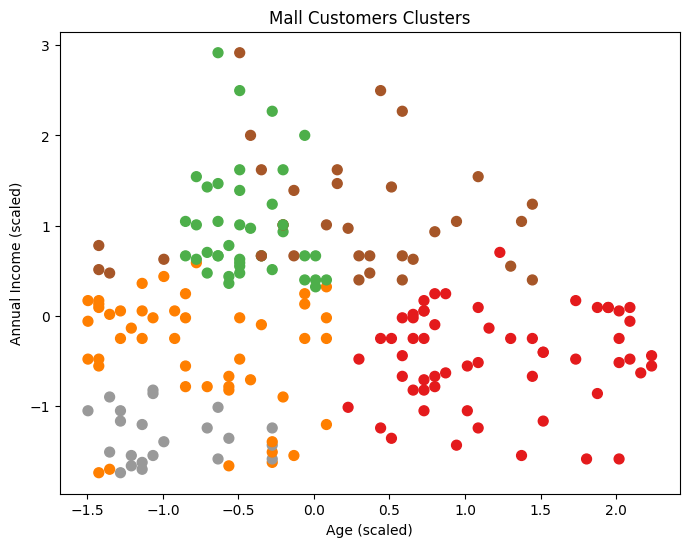

In [ ]:
import matplotlib.pyplot as plt

X_scaled = pipeline['prep'].transform(df.drop('CustomerID', axis=1))

plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=df['Cluster'], cmap='Set1', s=50)
plt.xlabel('Age (scaled)')
plt.ylabel('Annual Income (scaled)')
plt.title('Mall Customers Clusters')
plt.show()